# ESP-Fi HAR CSI Data Format + Visualization

This notebook inspects the ESP-Fi HAR `.mat` sample format and creates useful CSI plots, including a subcarrier-over-time heatmap.

In [3]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


In [4]:
def find_data_root() -> Path:
    candidates = [
        Path('../ModelCode/Data'),
        Path('ModelCode/Data'),
        Path('../Data'),
        Path('Data'),
    ]

    for c in candidates:
        if c.exists() and (c / 'train_amp').exists() and (c / 'test_amp').exists():
            return c.resolve()

    raise FileNotFoundError(
        'Could not find dataset root. Expected a folder containing train_amp/ and test_amp/. '
        f'Tried: {[str(x) for x in candidates]}'
    )


DATA_ROOT = find_data_root()
DATA_ROOT


WindowsPath('C:/Users/stef4/Desktop/ZoeCare/ESP-Fi-HAR-experiments/ModelCode/Data')

In [5]:
split = 'train_amp'
split_dir = DATA_ROOT / split

activities = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
rows = []
for act in activities:
    for p in sorted((split_dir / act).glob('*.mat')):
        rows.append(
            {
                'split': split,
                'activity_folder': act,
                'filename': p.name,
                'path': str(p.resolve()),
            }
        )

manifest = pd.DataFrame(rows)

print(f'Data root: {DATA_ROOT}')
print(f'Split: {split}')
print(f'Activities found: {len(activities)} -> {activities}')
print(f'Total .mat samples: {len(manifest)}')

display(manifest.head(10))
display(
    manifest.groupby('activity_folder', as_index=False)
    .size()
    .rename(columns={'size': 'num_samples'})
    .sort_values('activity_folder')
)


Data root: C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-experiments\ModelCode\Data
Split: train_amp
Activities found: 7 -> ['arm_wave', 'fall', 'jump', 'run', 'squat', 'turn', 'walk']
Total .mat samples: 490


,split,activity_folder,filename,path
0,train_amp,arm_wave,3-2-5-1.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
1,train_amp,arm_wave,3-2-5-10.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
2,train_amp,arm_wave,3-2-5-2.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
3,train_amp,arm_wave,3-2-5-3.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
4,train_amp,arm_wave,3-2-5-4.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
5,train_amp,arm_wave,3-2-5-5.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
6,train_amp,arm_wave,3-2-5-6.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
7,train_amp,arm_wave,3-2-5-7.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
8,train_amp,arm_wave,3-2-5-8.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...
9,train_amp,arm_wave,3-2-5-9.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...


,activity_folder,num_samples
0,arm_wave,70
1,fall,70
2,jump,70
3,run,70
4,squat,70
5,turn,70
6,walk,70


In [6]:
# Parse filename pattern: X-Y-Z-M.mat
pattern = re.compile(r'^(?P<scene>\d+)-(?P<subject>\d+)-(?P<activity_id>\d+)-(?P<trial>\d+)\.mat$')
meta = manifest['filename'].str.extract(pattern)
for c in ['scene', 'subject', 'activity_id', 'trial']:
    meta[c] = pd.to_numeric(meta[c], errors='coerce')

manifest_meta = pd.concat([manifest, meta], axis=1)

display(manifest_meta.head(10))
display(manifest_meta[['scene', 'subject', 'activity_id', 'trial']].describe())


,split,activity_folder,filename,path,scene,subject,activity_id,trial
0,train_amp,arm_wave,3-2-5-1.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,1
1,train_amp,arm_wave,3-2-5-10.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,10
2,train_amp,arm_wave,3-2-5-2.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,2
3,train_amp,arm_wave,3-2-5-3.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,3
4,train_amp,arm_wave,3-2-5-4.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,4
5,train_amp,arm_wave,3-2-5-5.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,5
6,train_amp,arm_wave,3-2-5-6.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,6
7,train_amp,arm_wave,3-2-5-7.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,7
8,train_amp,arm_wave,3-2-5-8.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,8
9,train_amp,arm_wave,3-2-5-9.mat,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,3,2,5,9


,scene,subject,activity_id,trial
count,490.0,490.000000,490.000000,490.000000
mean,3.0,5.000000,4.000000,5.500000
std,0.0,2.002044,2.002044,2.875217
min,3.0,2.000000,1.000000,1.000000
25%,3.0,3.000000,2.000000,3.000000
50%,3.0,5.000000,4.000000,5.500000
75%,3.0,7.000000,6.000000,8.000000
max,3.0,8.000000,7.000000,10.000000


In [7]:
KEY_CANDIDATES = ['CSIamp', 'csi_amp', 'CSI_amp', 'amp']

def load_csi_amp(mat_path: Path, key_candidates=KEY_CANDIDATES):
    mat = sio.loadmat(str(mat_path))

    data = None
    used_key = None
    for key in key_candidates:
        if key in mat:
            data = np.asarray(mat[key], dtype=np.float32)
            used_key = key
            break

    if data is None:
        raise KeyError(f'No CSI amplitude key found in {mat_path}. Tried: {key_candidates}')

    # Normalize orientation to (time, subcarrier) = (950, 52)
    if data.shape == (52, 950):
        data = data.T
    elif data.ndim == 3 and data.shape[0] == 1 and data.shape[1:] == (950, 52):
        data = data[0]

    if data.shape != (950, 52):
        raise ValueError(f'Unexpected CSI shape {data.shape} in {mat_path}')

    visible_keys = sorted([k for k in mat.keys() if not k.startswith('__')])
    return data, used_key, visible_keys

sample_idx = 0
sample_path = Path(manifest_meta.iloc[sample_idx]['path'])
sample_x, used_key, visible_keys = load_csi_amp(sample_path)

print(f'Sample file: {sample_path.name}')
print(f'Loaded key: {used_key}')
print(f'Keys in .mat: {visible_keys}')
print(f'Shape (time, subcarrier): {sample_x.shape}')
print(f'Dtype: {sample_x.dtype}')
print(f'Min/Max: {sample_x.min():.4f} / {sample_x.max():.4f}')
print(f'Mean/Std: {sample_x.mean():.4f} / {sample_x.std():.4f}')


Sample file: 3-2-5-1.mat
Loaded key: CSIamp
Keys in .mat: ['CSIamp']
Shape (time, subcarrier): (950, 52)
Dtype: float32
Min/Max: 21.4709 / 129.5222
Mean/Std: 52.0460 / 9.4209


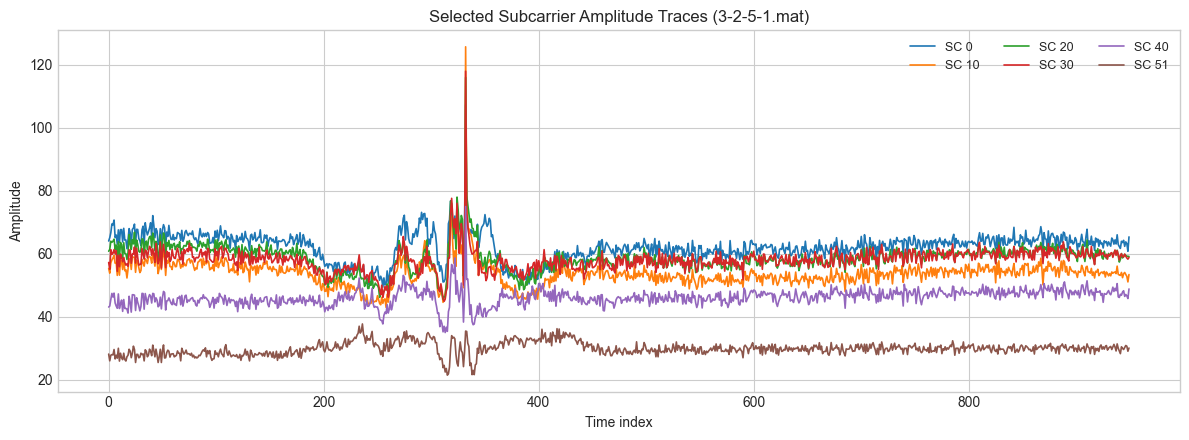

In [8]:
# Time-series for selected subcarriers
time_idx = np.arange(sample_x.shape[0])
selected_subcarriers = np.linspace(0, sample_x.shape[1] - 1, 6, dtype=int)

fig, ax = plt.subplots(figsize=(12, 4.5))
for sc in selected_subcarriers:
    ax.plot(time_idx, sample_x[:, sc], linewidth=1.2, label=f'SC {sc}')

ax.set_title(f'Selected Subcarrier Amplitude Traces ({sample_path.name})')
ax.set_xlabel('Time index')
ax.set_ylabel('Amplitude')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


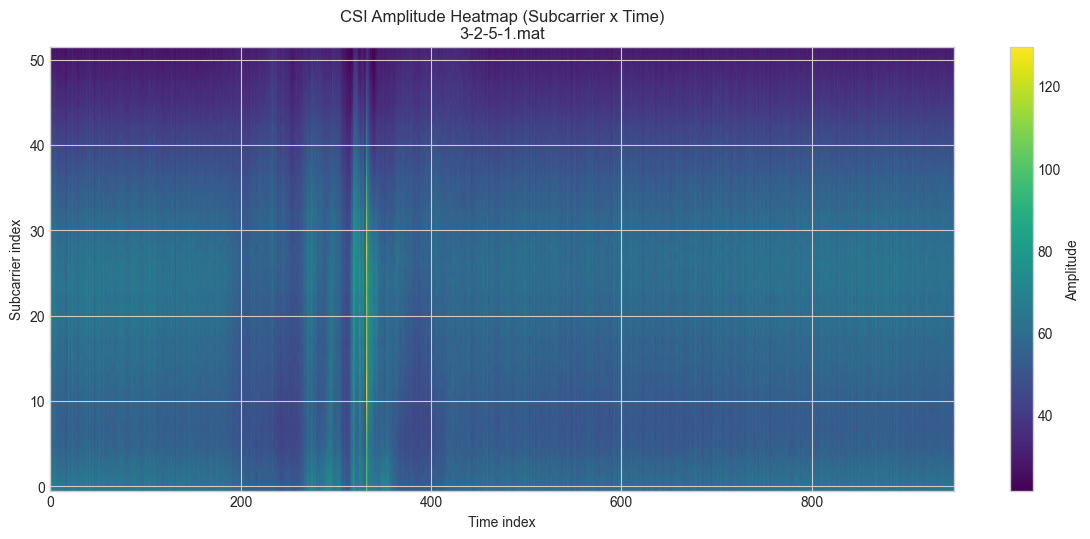

In [9]:
# Heatmap over time for each subcarrier
fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(
    sample_x.T,
    aspect='auto',
    origin='lower',
    cmap='viridis',
)

ax.set_title(f'CSI Amplitude Heatmap (Subcarrier x Time)\n{sample_path.name}')
ax.set_xlabel('Time index')
ax.set_ylabel('Subcarrier index')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Amplitude')
plt.tight_layout()
plt.show()


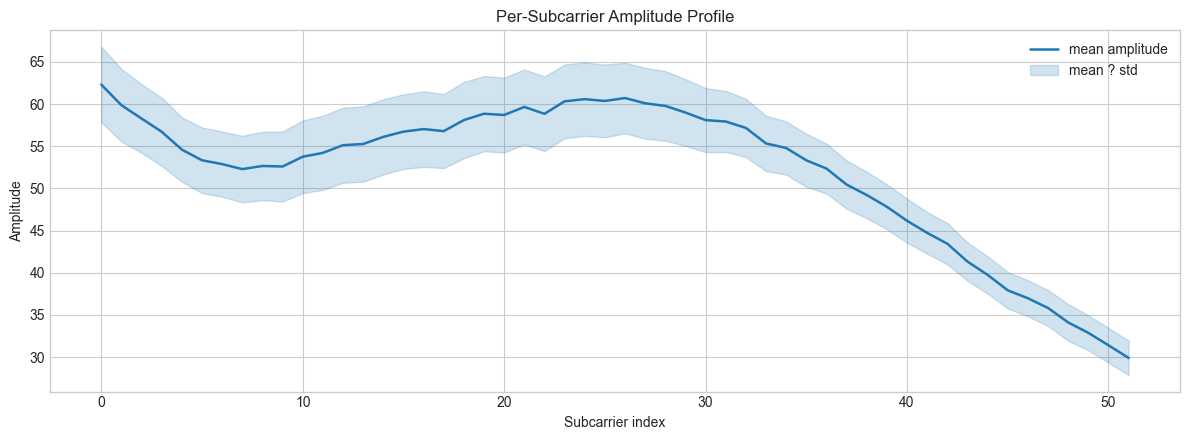

In [ ]:
# Per-subcarrier statistics
sub_idx = np.arange(sample_x.shape[1])
sub_mean = sample_x.mean(axis=0)
sub_std = sample_x.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(sub_idx, sub_mean, color='tab:blue', linewidth=1.8, label='mean amplitude')
ax.fill_between(
    sub_idx,
    sub_mean - sub_std,
    sub_mean + sub_std,
    color='tab:blue',
    alpha=0.2,
    label='mean +/- std',
)

ax.set_title('Per-Subcarrier Amplitude Profile')
ax.set_xlabel('Subcarrier index')
ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.show()


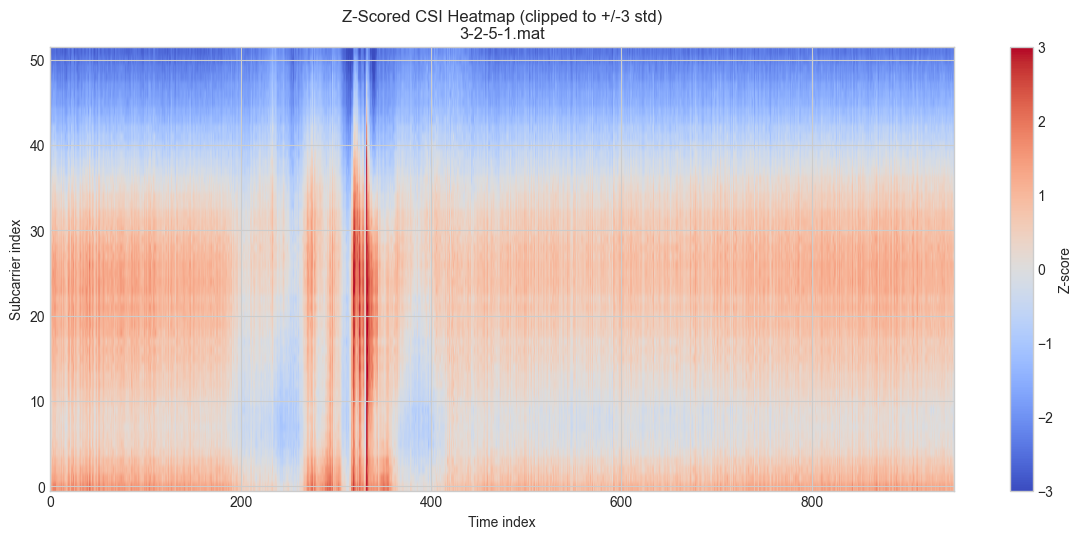

In [11]:
# Optional: normalized view matching training-time Z-score normalization
sample_x_norm = (sample_x - sample_x.mean()) / (sample_x.std() + 1e-8)

fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(
    sample_x_norm.T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',
    vmin=-3,
    vmax=3,
)

ax.set_title(f'Z-Scored CSI Heatmap (clipped to +/-3 std)\n{sample_path.name}')
ax.set_xlabel('Time index')
ax.set_ylabel('Subcarrier index')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Z-score')
plt.tight_layout()
plt.show()
